In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [21]:
def glass_brain_plot(df, value_col, idx_col, title=None, cmap='Reds', vmax=None, vmin=None, display_mode='lyrz'):
        from nilearn import image, plotting
        from matplotlib.colors import Normalize
        import matplotlib.gridspec as gridspec
        import matplotlib.cm as cm
        from nilearn import datasets

        df = pd.DataFrame({
                'value' : df[value_col],
                'region_idx' : df[idx_col]
            })
        # Load the 3D labeled atlas NIfTI
        label_img = image.load_img('data/wlabel_sPR06786_AD151295-0012-00001-000176-01_MT_ants.nii') # old : data/labels_neuromorphics_extra.nii (we don't know the patient) or data/wlabel_sPR06786_AD151295-0012-00001-000176-01_MT.nii (from ferath)
        label_data = label_img.get_fdata()

        # Make an empty stat map
        stat_data = np.zeros_like(label_data, dtype=float)

        # Fill in stat map based on region values
        for region_id, value in zip(df['region_idx'], df['value']):
            stat_data[label_data == region_id] = value

        #stat_data[np.abs(stat_data) < 1e-4] = 0
        #print(np.unique(stat_data, return_counts=True))
        # Create a new NIfTI image
        # Zero-out values outside the MNI brain
        brain_mask = datasets.load_mni152_brain_mask()
        brain_mask_res = image.resample_to_img(brain_mask, label_img, interpolation='nearest')
        mask_data = brain_mask_res.get_fdata().astype(bool)
        stat_data[~mask_data] = 0

        stat_img = image.new_img_like(label_img, stat_data)
        if not vmax:
            return plotting.plot_glass_brain(
            stat_img,
            display_mode=display_mode,  # Show all orthogonal projections
            colorbar=True,
            cmap=cmap,
            threshold=1e-6,
            #vmin=vmin,
            #vmax=vmax,
            title=title,
            plot_abs=False
        )
        else:
            if not vmin:
                vmin=0
            display = plotting.plot_glass_brain(
                stat_img,
                display_mode=display_mode,
                colorbar=True,
                cmap=cmap,
                cbar_tick_format='%i',
                vmin=vmin,
                vmax=vmax,
                threshold=1e-6,
                title=title,
                plot_abs=False
            )
            """
            # Shrink main plot area to leave space for colorbar
            fig = plt.gcf()
            # Manually resize each axes object to free space on the right
            for ax in fig.axes:
                pos = ax.get_position()
                ax.set_position([pos.x0, pos.y0, pos.width * 0.85, pos.height])  # shrink width

            # Create colorbar manually in reserved space
            # Add a new axis for the horizontal colorbar at the bottom
            cax = fig.add_axes([0.35, 0.08, 0.3, 0.02])  # [left, bottom, width, height]

            norm = Normalize(vmin=0, vmax=vmax)
            sm = cm.ScalarMappable(norm=norm, cmap=cmap)
            # sm = cm.ScalarMappable(norm=norm, cmap=plt.get_cmap(cmap))
            sm.set_array([])

            cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
            cbar.set_ticks(np.arange(0, vmax + 1, 1))"""


            return display 

In [22]:
df = pd.read_csv('output_pred/shap_original_long.csv')

In [23]:
df

,region_name,region_index,shap_value,feature_value
0,Right Accumbens Area,23,0.020384,0.292
1,Left Accumbens Area,30,-0.006048,0.348
2,Brain Stem,35,0.082216,0.493
3,Right Caudate,36,-0.103642,1.990
4,Left Caudate,37,-0.080945,2.079
...,...,...,...,...
153,Right hi_SPAM_CA1-3,243,-0.166904,1.995
154,Left hi_SPAM_CA4-DG,244,-0.072788,0.128
155,Right hi_SPAM_CA4-DG,245,-0.018975,0.136
156,Left hi_SPAM_subiculum,246,-0.189383,0.886


In [24]:
df['shap_value'].describe()

count    158.000000
mean       0.007596
std        0.089902
min       -0.192640
25%       -0.021931
50%       -0.001386
75%        0.023868
max        0.530132
Name: shap_value, dtype: float64

/tmp/ipykernel_10766/80189376.py:28: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  brain_mask_res = image.resample_to_img(brain_mask, label_img, interpolation='nearest')
/tmp/ipykernel_10766/80189376.py:28: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  brain_mask_res = image.resample_to_img(brain_mask, label_img, interpolation='nearest')


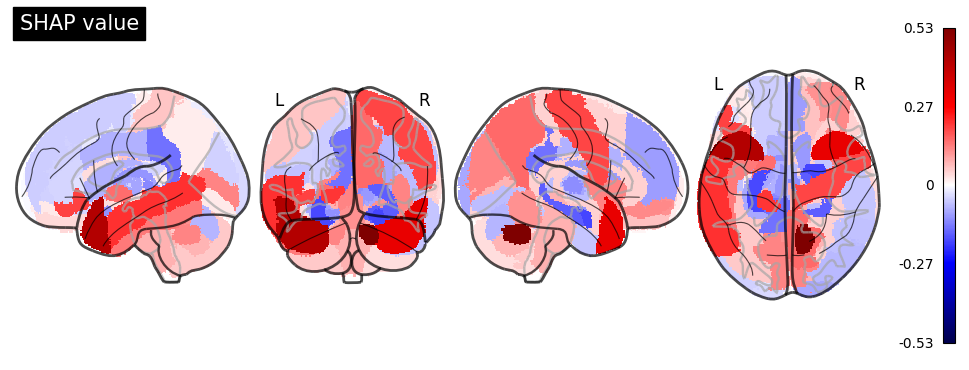

In [25]:
_fig = glass_brain_plot(
    df=df, 
    value_col='shap_value',
    idx_col='region_index',
    title=f"SHAP value", 
    display_mode='lyrz',
    cmap='seismic')
#_fig.savefig(f"figs/glm_LI/glasser/count_mod/{_beta}_glass_brain.png")
plt.show()